# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
loan_df = pd.read_csv('loan_data.csv')
loan_df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,78,male,Associate,83625.682134,25,OWN,17962.746070,HOMEIMPROVEMENT,5.561095,0.214799,22,652.222868,No,0
44996,27,male,Associate,29606.127102,21,OWN,19442.209516,MEDICAL,8.098525,0.656695,8,620.191145,No,0
44997,21,male,Doctorate,52712.989853,15,MORTGAGE,8712.004271,PERSONAL,9.326687,0.165272,10,630.333185,No,0
44998,60,male,Associate,77755.389249,15,RENT,2688.617555,EDUCATION,7.803261,0.034578,19,706.510547,No,1


### Loan status by AGE

In [2]:
loan_df['loan_status'] = loan_df['loan_status'].astype('category')

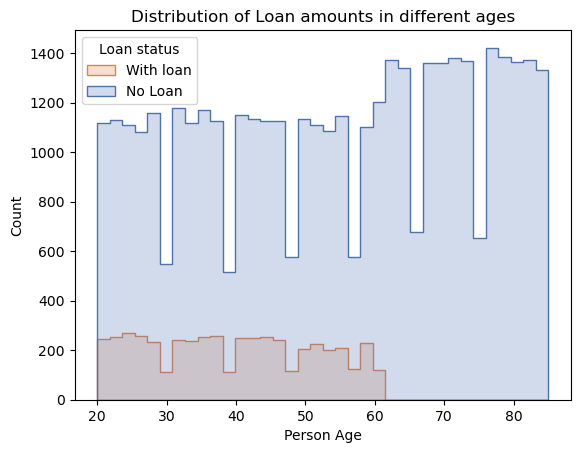

In [3]:
sns.histplot(x = loan_df['person_age'], data = loan_df, hue = 'loan_status', element = 'step', palette = 'deep')
plt.title("Distribution of Loan amounts in different ages")
plt.xlabel('Person Age')
plt.legend(['With loan', 'No Loan'], title = 'Loan status')
plt.show()

C:\Users\vykha\AppData\Local\Temp\ipykernel_37484\87919243.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='person_age',


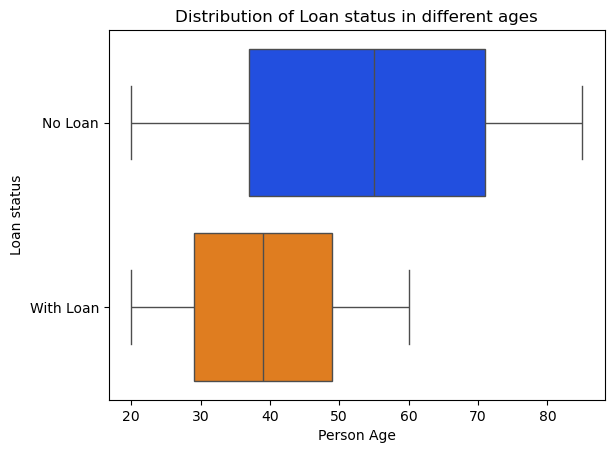

In [4]:
sns.boxplot(x='person_age',
            y= 'loan_status',
            data = loan_df,
            palette = 'bright')
plt.title("Distribution of Loan status in different ages")
plt.xlabel('Person Age')
plt.ylabel('Loan status')
original_positions = [1,0]
newlabels = ['With Loan', 'No Loan',]
plt.yticks(original_positions, newlabels)
plt.show()

It is obvious that from the boxplot, it is shown that young people from 20-60,especially around 40, usually have loan while people with no loan can be up to 80. Moreover, people around 50-60 higher chance don't have loan. 

### Loan status by SEX

In [5]:
gender_tab = pd.crosstab(loan_df['person_gender'], loan_df['loan_status'], normalize = 'index') * 100
gender_tab

loan_status,0,1
person_gender,,
female,88.972025,11.027975
male,89.228895,10.771105


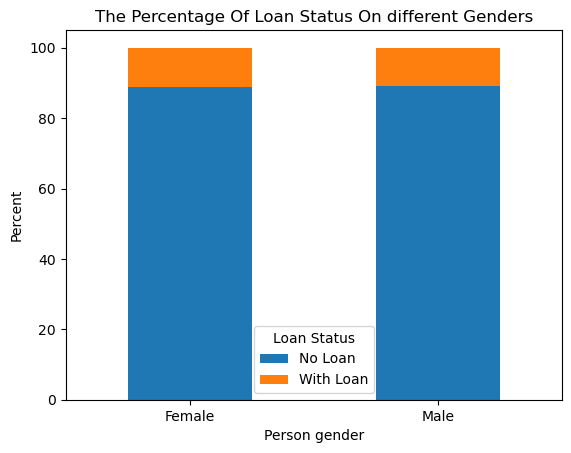

In [6]:
gender_tab.plot(kind = 'bar',
               stacked = True)
plt.title("The Percentage Of Loan Status On different Genders")
plt.ylabel('Percent')
plt.xlabel('Person gender')
plt.xticks([0,1],['Female', 'Male'], rotation = 0)
plt.legend(['No Loan', 'With Loan'], title = 'Loan Status')
plt.show()

From the bar chart, I can see that the percentage of female and male have loan and don't have loan are nearly identical, so gender is not a feature that affects loan status

### Loan status by Person Income

C:\Users\vykha\AppData\Local\Temp\ipykernel_37484\2935204510.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='person_income',


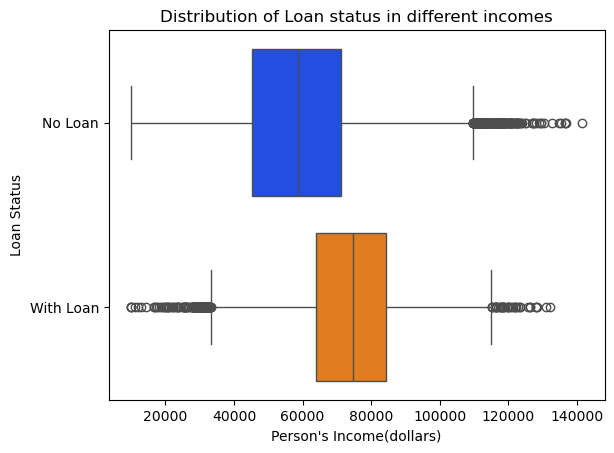

In [7]:
sns.boxplot(x='person_income',
            y= 'loan_status',
            data = loan_df,
            palette = 'bright')
plt.title("Distribution of Loan status in different incomes")
plt.xlabel("Person's Income(dollars)")
plt.ylabel('Loan Status')
original_positions = [1,0]
newlabels = ['With Loan', 'No Loan',]
plt.yticks(original_positions, newlabels)
plt.show()

Based on the boxplots, individuals with loans tend to have a higher median income 70,000 compared to those without loans 60,000. The "With Loan" group also shows outliers at both extremes (as low as 10,000 and as high as 140,000, suggesting that income alone is not very reliable predictor of loan status.

### Loan status by Person Home ownership

In [8]:
home_tab = pd.crosstab(loan_df['person_home_ownership'], loan_df['loan_status'], normalize = 'index') * 100
home_tab

loan_status,0,1
person_home_ownership,,
MORTGAGE,98.696475,1.303525
OWN,75.652894,24.347106
RENT,91.774651,8.225349


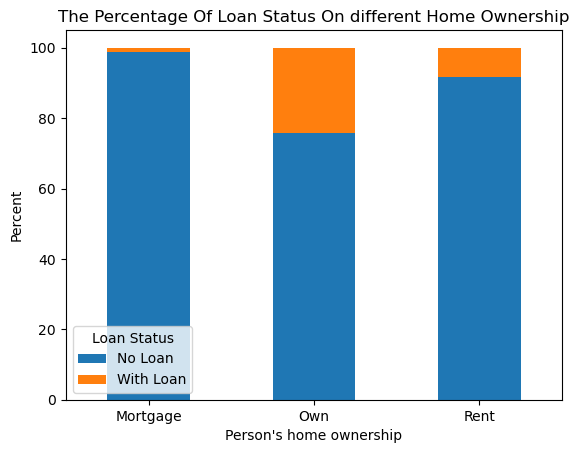

In [9]:
home_tab.plot(kind = 'bar',
               stacked = True)
plt.title("The Percentage Of Loan Status On different Home Ownership")
plt.ylabel('Percent')
plt.xlabel("Person's home ownership")
plt.xticks([0,1,2],['Mortgage', 'Own', 'Rent'], rotation = 0)
plt.legend(['No Loan', 'With Loan'], title = 'Loan Status')
plt.show()

Home ownership type appears to have a relationship with loan status, with homeowners showing the highest likelihood of taking a loan at 24%, compared to renters at 8% and mortgage holders at just 1%. The striking difference between the "Own" group and the other two groups suggests that owning a home outright may enable or encourage additional borrowing, potentially by using property as collateral. Overall, home ownership category seems to be a more distinguishing feature of loan status than income alone, making it a potentially useful predictor in a classification model.

### Loan status by Loan intent

In [10]:
loan_intent_tab = pd.crosstab(loan_df['loan_intent'], loan_df['loan_status'], normalize = 'index') * 100
loan_intent_tab

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,93.342175,6.657825
EDUCATION,81.270948,18.729052
HOMEIMPROVEMENT,80.605411,19.394589
MEDICAL,93.494326,6.505674
PERSONAL,92.659560,7.340440
VENTURE,93.254704,6.745296


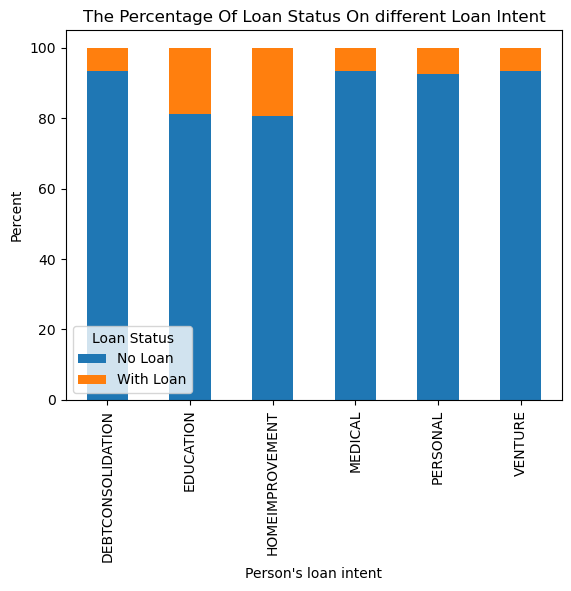

In [11]:
loan_intent_tab.plot(kind = 'bar',
               stacked = True)
plt.title("The Percentage Of Loan Status On different Loan Intent")
plt.ylabel('Percent')
plt.xlabel("Person's loan intent")
plt.legend(['No Loan', 'With Loan'], title = 'Loan Status')
plt.show()

Loan intent shows some variation in loan status across categories, with Education and Home Improvement 20% having notably higher loan rates compared to other intents which cluster around just 7–8%.

### Loan status by credit score

C:\Users\vykha\AppData\Local\Temp\ipykernel_37484\1384349499.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='credit_score',


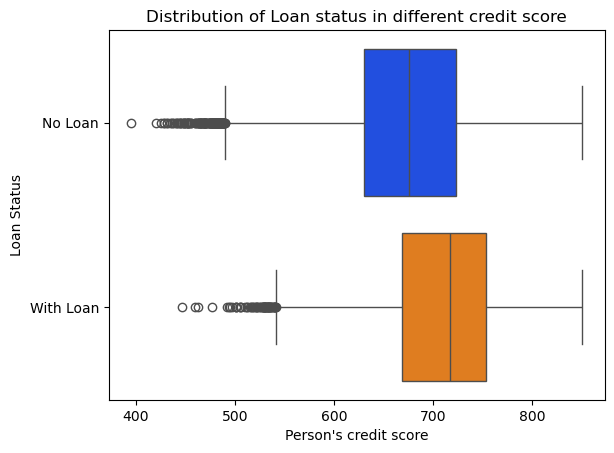

In [12]:
sns.boxplot(x='credit_score',
            y= 'loan_status',
            data = loan_df,
            palette = 'bright')
plt.title("Distribution of Loan status in different credit score")
plt.xlabel("Person's credit score")
plt.ylabel('Loan Status')
original_positions = [1,0]
newlabels = ['With Loan', 'No Loan',]
plt.yticks(original_positions, newlabels)
plt.show()

Despite common expectations, credit score shows surprisingly little separation between the two loan status groups, with nearly identical medians (~675 for No Loan vs ~700 for With Loan). Both groups share a similar upper range of up to ~850, though the "With Loan" group contains more extreme low-score outliers below 500. This suggests that with higher credit score alone is not a too strong discriminator of loan status in this dataset, but still higher credit score has higher chance with loan

### Loan status by person education

In [13]:
education_tab = pd.crosstab(loan_df['person_education'], loan_df['loan_status'], normalize = 'index') * 100
education_tab

loan_status,0,1
person_education,,
Associate,89.684493,10.315507
Bachelor,88.962127,11.037873
Doctorate,89.050773,10.949227
High School,89.123270,10.876730
Master,88.814393,11.185607


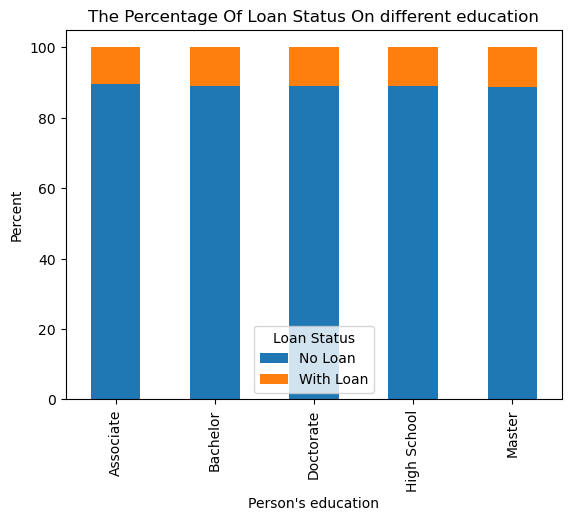

In [14]:
education_tab.plot(kind = 'bar',
               stacked = True)
plt.title("The Percentage Of Loan Status On different education")
plt.ylabel('Percent')
plt.xlabel("Person's education")
plt.legend(['No Loan', 'With Loan'], title = 'Loan Status')
plt.show()

Education level shows virtually no meaningful difference in loan status across all five categories, with the "With Loan" rate ranging only narrowly from ~10% to ~12% — a spread of just 2 percentage points.

The institution should be most concerned about home ownership and age patterns, as both show statistically visible disparities that could attract regulatory scrutiny. While other variables show no discriminatory signals, the ~23 percentage point gap between Owners and Mortgage holders, combined with a ~16-year median age gap between loan groups, are red flags that warrant an internal audit and legal review before they become regulatory violations.